# 03 Test Environment Simulated Aneling Algorithm

This notebook is to serve as a test ground for building an numerical shortest path optimiser following building a terrain we now will build a optimiser to solve this. I will use a simulated annealing algorithm. First lets initialise the terrain.

In [37]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("../src")
from terrain.terrain import Terrain
from geometry.endpoints import Endpoints
from geometry.path import Path
from geometry.generators import straight_line_path


### terrain ### 
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)

terrain.add_hill(
    centre=(50, 50),
    peak_cost=10,
    radius=20

)


### boundarys ###

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary_df = boundary.to_dataframe()


terrain.grid.shape
terrain_df = terrain.to_dataframe()

### Initial Path
initial_path = straight_line_path(
    start=boundary.start,
    end=boundary.end,
    num_points=100
)

initial_path_df = initial_path.to_dataframe()

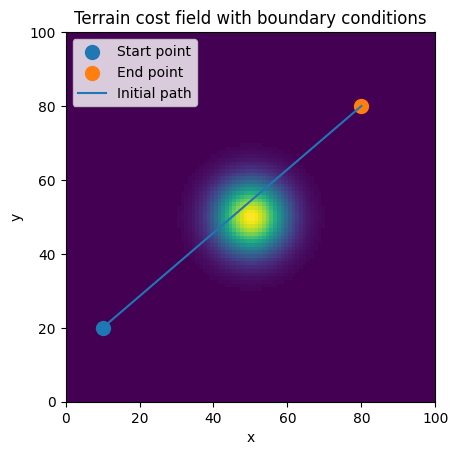

In [38]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    initial_path_df["x"],
    initial_path_df["y"],
    label="Initial path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

I am wanting to minimise this cost function

In [39]:
from cost_functions.terrain_cost import terrain_cost

cost = terrain_cost(
    initial_path,
    terrain
)

print(cost)

156.09657794974427


I have a function that performs a random shift move on an interior path segment this will give me a number of candiate paths

I then apply a simulated annealing algo to optimise for best solution

In [40]:
from optimisation.annealing import simulated_annealing, path_history_to_df


best_path, best_cost, history, path_history = simulated_annealing(
    initial_path=initial_path,
    terrain=terrain,
    iterations=10000,
    initial_temperature=5,
    cooling_rate=0.995,
    sigma=0.1,
    alpha=10
)

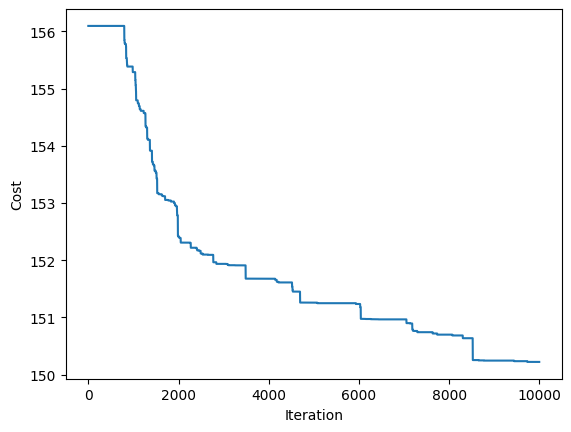

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

plt.plot(
    history_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [42]:

best_path_df = best_path.to_dataframe()

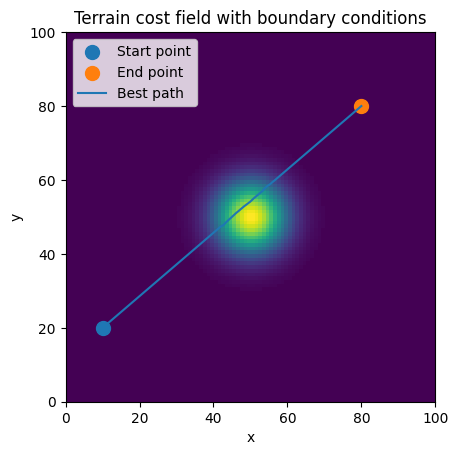

In [43]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_df["x"],
    best_path_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [61]:
from optimisation.annealing import simulated_segment_annealing


best_path_segment, best_cost_segment, history_segment, path_history_segment = simulated_segment_annealing(
    initial_path=initial_path,
    terrain=terrain,
    iterations=2000,
    initial_temperature=5,
    cooling_rate=0.995,
    sigma=0.3,
    alpha=10
)


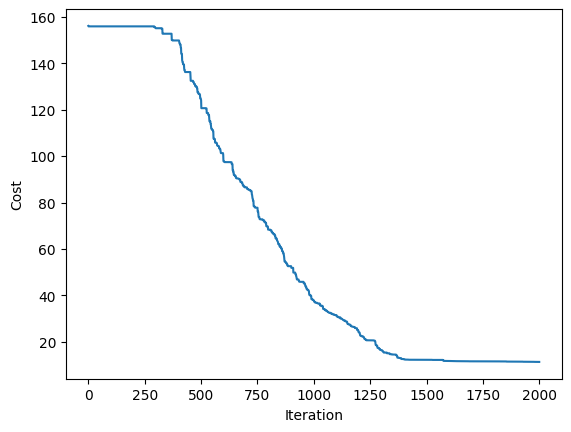

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

history_segment_df = pd.DataFrame(history_segment)

plt.plot(
    history_segment_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [63]:

best_path_segment_df = best_path_segment.to_dataframe()


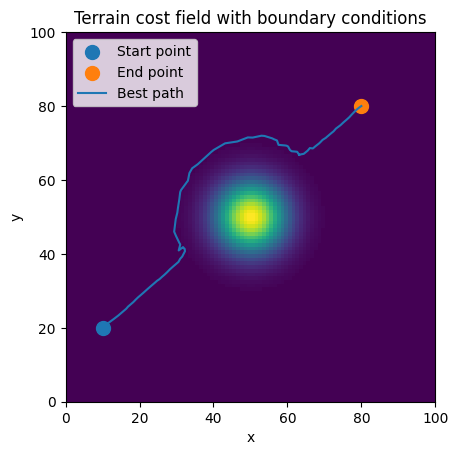

In [64]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_segment_df["x"],
    best_path_segment_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [65]:
print(best_path_segment_df.to_string(index=False))

 point         x         y
     0 10.000000 20.000000
     1 10.707071 20.606061
     2 11.414141 21.212121
     3 12.985190 22.354508
     4 14.247739 23.321730
     5 14.954809 23.927791
     6 15.661880 24.533851
     7 16.368951 25.139912
     8 16.787066 25.618203
     9 16.859418 25.711847
    10 17.566488 26.317907
    11 18.273559 26.923968
    12 18.788810 27.442879
    13 18.786212 27.464127
    14 19.572523 28.221443
    15 20.279594 28.827504
    16 20.986665 29.433564
    17 21.919215 30.278639
    18 22.849581 31.093364
    19 23.556651 31.699424
    20 24.263722 32.305485
    21 24.746037 32.732240
    22 25.419448 33.186436
    23 26.037870 33.760089
    24 26.744941 34.366150
    25 27.496081 35.077596
    26 28.249040 35.851936
    27 29.101534 36.606237
    28 29.808605 37.212298
    29 30.515676 37.818358
    30 30.991177 38.676532
    31 31.535085 39.278246
    32 31.876719 39.942219
    33 32.279191 40.715689
    34 32.280262 40.838537
    35 32.173175 41.415085
 

In [66]:
print(len(path_history_segment))

807


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8, 8))

# Plot terrain background
ax.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot start/end points
ax.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

ax.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

# Empty line for animation
line, = ax.plot([], [], linewidth=2, label="Current path")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated Annealing Path Evolution")

ax.legend()


def update(frame):
    """
    Update path for each animation frame.
    """

    path = path_history_segment[frame]

    points = path.points

    line.set_data(
        points[:, 0],
        points[:, 1]
    )

    ax.set_title(
        f"Iteration: {frame}"
    )

    return line,


animation = FuncAnimation(
    fig,
    update,
    frames=len(path_history_segment),
    interval=10,   # milliseconds between frames
    blit=True
)

animation.save(
    "/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/outputs/path_evolution.gif",
    writer="pillow",
    fps=100
)

plt.close()

Animation for posting and showing Yasemin

In [74]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Reduce frames for LinkedIn
linkedin_history = path_history_segment[::5]


fig, ax = plt.subplots(figsize=(6, 6))

# Plot terrain background
ax.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot start/end points
ax.scatter(
    boundary.start[0],
    boundary.start[1],
    s=80,
    label="Start"
)

ax.scatter(
    boundary.end[0],
    boundary.end[1],
    s=80,
    label="End"
)

# Empty path line
line, = ax.plot(
    [],
    [],
    linewidth=2,
    label="Optimised path"
)

# Iteration counter
iteration_text = ax.text(
    0.02,
    0.90,
    "",
    transform=ax.transAxes,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated Annealing Path Optimisation")

ax.legend()


def update(frame):

    path = linkedin_history[frame]

    points = path.points

    line.set_data(
        points[:, 0],
        points[:, 1]
    )

    # Calculate current path cost
    current_cost = terrain_cost(
        path,
        terrain
    )

    # Recover original iteration number
    iteration_text.set_text(
        f"Iteration: {frame * 5}\n"
        f"Cost: {current_cost:.2f}"
    )

    return line, iteration_text

animation = FuncAnimation(
    fig,
    update,
    frames=len(linkedin_history),
    interval=50,
    blit=True
)


animation.save(
    "/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/outputs/linkedin_path_cost_evolution.gif",
    writer="pillow",
    fps=20
)

plt.close()